# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Image Generative AI 코드 과제 🐻‍❄️



## 과제 목적
이번 과제에서는 이미지 생성 모델의 세 가지 큰 축인 **VAE**, **GAN**, **Diffusion**의 핵심 구현을 직접 코드로 뜯어보고, 마지막으로 Hugging Face의 사전학습 Diffusion 모델을 API처럼 불러와 실습해봅니다.
끝에는 직접 자기가 원하는 모델을 선택 후 써보는 경험까지 고안해보며 활용 능력까지 얻을 수 있도록 해봅니다.




## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — 마지막에 모델 활용한 [hugging face] question 4 부분만




- **VAE (Variational AutoEncoder)**: 입력 데이터를 확률적인 잠재 공간(latent space)으로 압축한 뒤, 그 분포에서 샘플링하여 새로운 데이터를 생성하는 모델
- **GAN (Generative Adversarial Network)**: Generator(위조지폐범)와 Discriminator(경찰)가 서로 경쟁하며 학습하는 모델
- **Diffusion Model**: 이미지에 점진적으로 노이즈를 주입(Forward process)한 뒤, 그 노이즈를 단계적으로 제거(Reverse process)하도록 학습하여 무작위 노이즈로부터 이미지를 생성하는 모델

Part 1~3에서는 세 모델을 MNIST로 직접 구현/학습하며 원리를 비교하고, Part 4에서는 Hugging Face `diffusers` 라이브러리로 실제 학습된 대형 Diffusion 모델을 실습합니다.


### **모듈 임포트 및 디바이스 설정**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


### **데이터셋 준비 (MNIST dataset)**

In [2]:
batch_size = 128
epochs = 15

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 522kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


## **Part 1. VAE (Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원


참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [3]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 평균을 계산하는 레이어)
        logvar = self.fc22(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 로그 분산을 계산하는 레이어)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # 🤔 빈칸을 채워주세요 (Reparameterization Trick 수식)

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


**✍️ 위에서 채운 `encode` / `reparameterize` 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* encode는 입력 데이터를 주어진 잠재 공간의 확률 분포로 매핑하는 역할을 수행한다.코드적으로는 self.fc1에 ReLU를 적용해 h1을 얻고, h1을 서로 다른 두 선형 레이어 self.fc21, self.fc22에 각각 통과시켜 평균과 로그분산을 얻는 구조로 되어있다. reparameterize는 미분이 불가능했던 변수를 다른 변수와의 조합을 통해 미분이 가능하도록 만든다. 입력으로 받은 mu와 logvar을 가지고 std는 torch.exp(0.5 * logvar)로 만들고, eps는 torch.randn_like(std)로 만들어준다. torch.randn_like는 입력과 동일한 모양으로 평균이 0이고 분산이 1인 정규분포에서 숫자를 뽑아 tensor를 만들어준다.


### **VAE loss (ELBO)**
* Reconstruction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정


In [4]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B  # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B  # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD  # 🤔 빈칸을 채워주세요

    return total_loss


**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* elbo_loss는 VAE의 loss function이다. 복원된 이미지가 원본 이미지와 얼마나 다른지와 잠재공간의 분포가 표준 정규분포와 얼마나 다른지를 합쳐서 계산한다. Reconstruction Loss + KL Divergence로 구성되어있다. BCE가 Reconstruction Loss, KLD가 KL Divergence이다. BCE는 디코더가 복원한 이미지와 원본 이미지 사이의 binary cross entropy를 전부 더한 뒤 배치 크기 B로 나눠 평균을 낸다.
KLD는 인코더가 만든 분포가 표준정규분포와 얼마나 다른지를 닫힌 형태 공식으로 계산하고 배치크기 B로 나눠 평균을 낸다. total_loss는 두 손실을 더해 최종 손실로 사용한다.


## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



* VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유는 생성된 잠재공간의 분포를 표준 정규분포와 가깝게 하기 위해서이다.


In [5]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/15] Train Loss: 1.3157 | Val Loss: 1.0346
Epoch [2/15] Train Loss: 0.9645 | Val Loss: 0.9340
Epoch [3/15] Train Loss: 0.9041 | Val Loss: 0.8998
Epoch [4/15] Train Loss: 0.8785 | Val Loss: 0.8796
Epoch [5/15] Train Loss: 0.8632 | Val Loss: 0.8667
Epoch [6/15] Train Loss: 0.8528 | Val Loss: 0.8600
Epoch [7/15] Train Loss: 0.8456 | Val Loss: 0.8531
Epoch [8/15] Train Loss: 0.8401 | Val Loss: 0.8493
Epoch [9/15] Train Loss: 0.8354 | Val Loss: 0.8451
Epoch [10/15] Train Loss: 0.8317 | Val Loss: 0.8417
Epoch [11/15] Train Loss: 0.8290 | Val Loss: 0.8405
Epoch [12/15] Train Loss: 0.8260 | Val Loss: 0.8363
Epoch [13/15] Train Loss: 0.8239 | Val Loss: 0.8359
Epoch [14/15] Train Loss: 0.8219 | Val Loss: 0.8348
Epoch [15/15] Train Loss: 0.8199 | Val Loss: 0.8318


**VAE sampling 시각화**

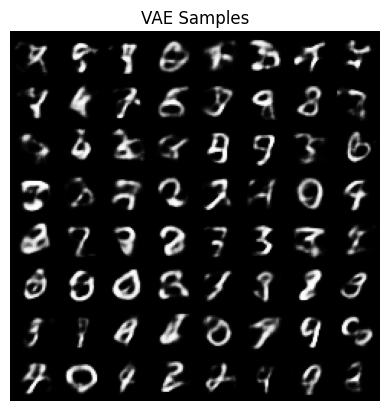

In [6]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


## **Part 2. DCGAN (Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - 마지막 layer에서 sigmoid를 통해 Real/Fake 확률값 출력


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [8]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [9]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))   # 🤔 빈칸을 채워주세요 (Generator의 입력)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))   # 🤔 빈칸을 채워주세요 (마지막 layer 통과)
        return x


**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* Generator.forward는 랜덤 잠재 벡터 z를 입력받아 transposed convolution을 여러 번 거치며 해상도를 높이고 채널 수는 줄여가는 구조로 중간 층마다 batchnorm과 relu로 학습의 안정성을 높이고 마지막층에서만 tanh를 적용해 출력을 [-1,1] 범위로 맞춰 노이즈로부터 28x28크기의 가짜 숫자 이미지를 생성한다.


In [10]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)


**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* Discriminator.forward는 28x28크기의 이미지를 입력받아 strided convolution을 반복 적용하여 해상도를 28 -> 14 -> 7 -> 3 로 줄이고 채널 수는 1 -> 64 -> 128 -> 256 으로 늘려가며 특징을 추출하는 구조로 각 층마다 leaky_relu로 약한 음수 기울기를 살려 죽은 뉴런 문제를 줄이다가 마지막 con4에서 채널을 1로 압축한 뒤 sigmoid를 적용해 0~1 사이의 확률값으로 변환하고 veiw와 squeeze로 배치 크기에 맞는 1차원 벡터 형태롤 반환한다.


In [11]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [12]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸을 채워주세요 (Generator는 D가 fake_img를 무엇으로 착각하길 원할까요?)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")


Epoch [1/15] Loss D: 0.8296 | Loss G: 1.6498
Epoch [2/15] Loss D: 0.9230 | Loss G: 1.4127
Epoch [3/15] Loss D: 0.9624 | Loss G: 1.3601
Epoch [4/15] Loss D: 0.9855 | Loss G: 1.3446
Epoch [5/15] Loss D: 0.9806 | Loss G: 1.3821
Epoch [6/15] Loss D: 1.0090 | Loss G: 1.3435
Epoch [7/15] Loss D: 0.9885 | Loss G: 1.3831
Epoch [8/15] Loss D: 1.0037 | Loss G: 1.3614
Epoch [9/15] Loss D: 0.9672 | Loss G: 1.4309
Epoch [10/15] Loss D: 0.9700 | Loss G: 1.4386
Epoch [11/15] Loss D: 0.9743 | Loss G: 1.4388
Epoch [12/15] Loss D: 0.9588 | Loss G: 1.4719
Epoch [13/15] Loss D: 0.9490 | Loss G: 1.4893
Epoch [14/15] Loss D: 0.9482 | Loss G: 1.5109
Epoch [15/15] Loss D: 0.9151 | Loss G: 1.5507


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 노이즈 z로 만든 fake_img와 실제 이미지 x에 각각 fake/real 라벨을 주어서 BCE Loss를 계산해 discriminator를 업데이트하고, 같은 fake_img를 다시 D에 통과시키고 이번엔 라벨을 real로 주어서 generator가 D를 속이는 방향으로 업데이트한다.


**DCGAN Sampling 시각화**

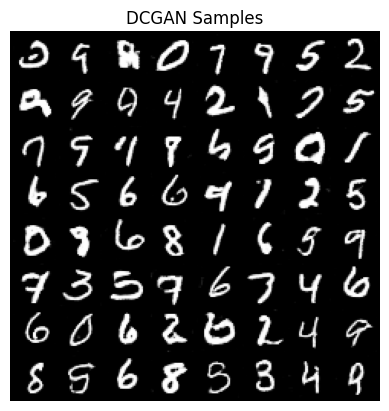

In [13]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

* VAE는 픽셀 단위의 평균값을 예측하는 손실 함수를 사용해 이미지가 흐릿해지고, DCGAN은 판별자와의 경쟁 학습을 통해 선명한 이미지를 생성한다.


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

* Generator가 너무 빨리 강해지면 다양한 이미지 대신 몇 가지 패턴만 반복 생성하는 Mode collapse가 발생하고 Discriminator가 너무 빨리 강해지면 D가 0에 가까워져 Generator에 전달되는 Vanishing gadient문제가 발생한다.

## **Part 3. Diffusion Model (DDPM) 원리 구현**

- **Forward process**: 원본 이미지 $x_0$에 $t$번에 걸쳐 점진적으로 Gaussian noise를 주입하여 $x_t$를 만드는 과정. Closed-form으로 한 번에 임의의 t 시점 노이즈 이미지를 계산할 수 있음
  $$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)$$

- **Reverse process**: 노이즈 $x_t$로부터 노이즈 $\epsilon$을 예측하는 신경망(주로 U-Net)을 학습시켜, $x_T$(순수 노이즈)부터 $x_0$까지 역으로 복원

- **손실함수의 단순화**: DDPM 논문의 핵심 기여 중 하나로, 복잡한 분포 비교 대신 신경망이 예측한 노이즈와 실제 주입된 노이즈 사이의 단순 MSE Loss만으로 학습이 가능함
  $$L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\, \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \,\right]$$

이번 파트에서는 **forward process와 손실함수, 노이즈 예측 네트워크의 핵심 구조를 직접 코드로 구현**하며 원리를 이해합니다. 다만 DDPM은 실제로는 대규모 U-Net을 오랜 시간 학습해야 제대로 된 이미지가 나오기 때문에, 짧은 실습 환경(Colab)에서 처음부터 학습시키기엔 한계가 있습니다. 그래서 우리가 구현한 것과 동일한 원리로 학습된 **Hugging Face의 사전학습 MNIST DDPM 모델**을 불러와 실제 reverse process 결과를 확인해봅니다.


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


### **Noise Schedule 정의**
$\beta_t$를 선형으로 증가시키며, $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$ 를 미리 계산해둡니다.


In [15]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* forward_diffusion은 x0에 timestep t별 계수를 곱해 가중합을 구하고 가우시안 노이즈를 더해서 원본 이미지에 단계적 노이즈 주입을 한 번의 연산으로 계산하며 손실 계산에 쓸 실제 노이즈도 함께 반환한다.


**Forward process 시각화**: t가 커질수록 이미지가 점점 순수 노이즈에 가까워지는 것을 확인해봅시다.

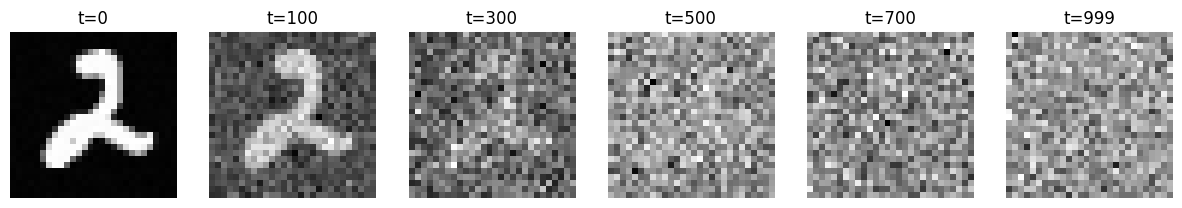

In [16]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


### **U-Net 기반 노이즈 예측 네트워크**
DDPM은 노이즈가 섞인 이미지 $x_t$와 timestep $t$를 입력받아 주입된 노이즈 $\epsilon$을 예측하는 신경망을 사용합니다. 아래는 skip connection을 포함한 축소된 U-Net 구조입니다. Downsampling에서 저장해둔 feature map을 Upsampling 단계에서 다시 이어붙여(concat), 공간 정보 손실을 줄이는 것이 핵심입니다.


In [17]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* SimpleUNet.forward의 timestep 결합 코드는 timestep이라는 숫자 정보를 이미지 특징 맵에 결합해 U-Net이 현재 몇 번째 노이즈 제거 단계인지 인식할 수 있게 해주는 역할을 한다. TimeEmbedding이 스칼라 t를 고차원 벡터 t_emb로 변환하고, time_proj 선형층이 이 벡터의 차원을 bottelneck의 채널수에 맞춘 뒤, unsqueeze(-1).unsqueeze(-1)로 (B, 256)모양을 (B, 256, 1, 1)로 바꿔 이미지 특징 h3의 모양과 맞춰준다. 모양을 맞춘 t_emb를 h3에 더하면 브로드캐스팅에 의해 동일한 timestep정보가 모든 공간 위치에 똑같이 반영된다.

### **DDPM Loss**
예측한 노이즈와 실제 주입한 노이즈 사이의 MSE Loss입니다.


In [18]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(predicted_noise, noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* ddpm_loss는 모델이 예측한 노이즈와 실제로 이미지에 섞였던 노이즈를 비교해서 오차를 계산하는 부분이다.
t = torch.randint로 배치마다 랜덤 timestep t를 뽑고, forwardPdiffusion으로 원본 이미지에 t만큼 노이즈를 실제롤 섞어 x_t와 정답 노이즈를 얻는다. model(x_t, t)로 모델이 x_t를 보고 노이지를 예측하고 MSE로 계산한다.


## **🙋 [Diffusion] Question 1**
DDPM은 왜 원본 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습할까요?

* 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습하는 이유는 t가 클수록 x_t에 원본 정보가 거의 남지 않아 x_0를 직접 맞히기는 매우 어렵지만, $\epsilon$은 항상 정규분포를 따르므로 timestep에 관계없이 예측 난이도와 스케일이 일정해 학습이 훨씬 안정적이기 때문이다.


In [19]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


### **사전학습된 DDPM으로 Reverse Process 결과 확인**

Hugging Face에는 우리가 위에서 구현한 것과 동일한 원리(forward process, 노이즈 예측 U-Net, MSE loss)로 MNIST를 학습시킨 DDPM 모델이 공개되어 있습니다. `DDPMPipeline`을 불러와 실제 reverse process가 어떻게 노이즈에서 숫자 이미지를 만들어내는지 확인해봅시다.


In [20]:
!pip install -q diffusers transformers accelerate safetensors

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

FrozenDict({'num_train_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'beta_schedule': 'squaredcos_cap_v2', 'trained_betas': None, 'variance_type': 'fixed_small', 'clip_sample': True, 'prediction_type': 'epsilon', 'thresholding': False, 'dynamic_thresholding_ratio': 0.995, 'clip_sample_range': 1.0, 'sample_max_value': 1.0, 'timestep_spacing': 'leading', 'steps_offset': 0, 'rescale_betas_zero_snr': False, '_class_name': 'DDPMScheduler', '_diffusers_version': '0.27.2'})


  0%|          | 0/200 [00:00<?, ?it/s]

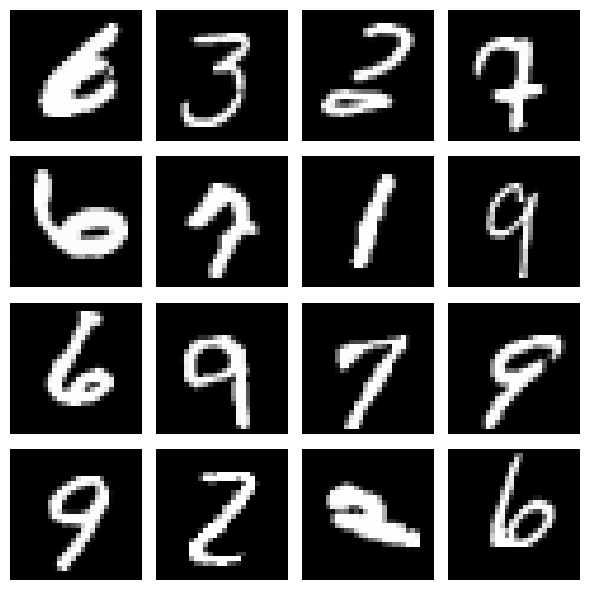

In [21]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

- DDPM은 VAE, GAN처럼 한 번의 순전파로 이미지를 만드는 게 아니라 노이즈에서 시작해 여러 스텝을 거치며 반복적으로 denoising하는 확률적 과정이기 때문에 초반 스텝의 작은 오차나 노이즈 realization이 뒤로 갈수록 누적되어 결과 품질 편차가 커진다.

## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.

앞선 실습 사진을 보고 하는 것이 아닌 이론적으로 비교해주시면 됩니다.아무래도 실습이다보니 이 결과로 비교하는 것은 이론적으로 틀릴 수도 있어서...



- 학습 안정성은 VAE와 Diffusion이 단일 손실함수로 안정적인 반면, GAN은 적재적 minmax 구조여서 mode collapse, vanishing gradient에 취약해 불안정하다.
- 생성 품질은 VAE가 픽셀 단위 재구성 손실 때문에 흐릿한 반면, GAN은 선명하지만 다양성이 부족할 수 있고, Diffusion은 점진적 denoising으로 품질과 다양성을 모두 높은 수준으로 달성하는 경우가 많다.
- 추론 속도는 VAE, GAN이 한 번의 순전파로 이미지를 생성해 빠른 반면, Diffusion은 많은 step의 반복적 denoising이 필요해 가장 느리다.

## **Part 4. Hugging Face `diffusers`로 사전학습 Diffusion 모델 실습**

Part 3에서 우리는 DDPM의 핵심 원리(forward process, 노이즈 예측 U-Net, MSE loss)를 직접 코드로 구현하고, MNIST 전용 사전학습 모델로 그 결과를 확인해봤습니다. 이번에는 훨씬 크고 복잡한 U-Net을 방대한 이미지-텍스트 데이터로 학습시킨 모델을 다뤄봅니다. 대표적으로 **Stable Diffusion**은 발표자료에서 다룬 것처럼 VAE + Diffusion(Latent Diffusion) + Cross-Attention 기반 Text Conditioning 구조를 가지고 있습니다.

Hugging Face의 `diffusers` 라이브러리를 사용하면 이런 사전학습 모델을 몇 줄의 코드로 불러와 사용할 수 있습니다. Colab에서는 **런타임 유형을 GPU로 설정**한 후 진행해주세요. (런타임 → 런타임 유형 변경 → T4 GPU)


In [22]:
!pip install -q diffusers transformers accelerate


### **4-1. Text-to-Image: Stable Diffusion**

프롬프트를 입력하면 그에 맞는 이미지를 생성해주는 `StableDiffusionPipeline`을 사용해봅니다. 내부적으로는 텍스트 프롬프트를 CLIP text encoder로 임베딩하고, 이를 조건으로 latent space에서 diffusion(denoising)을 수행한 뒤, VAE decoder로 pixel space 이미지를 복원합니다. (발표자료 33p의 Stable Diffusion 구조 참고)


In [23]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

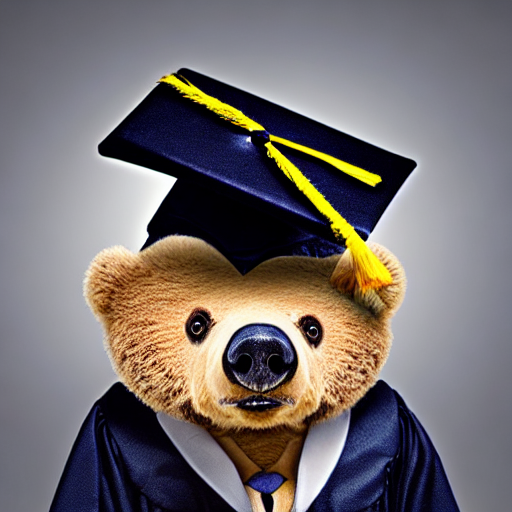

In [24]:
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"   # 🤔 원하는 프롬프트로 자유롭게 바꿔보세요

image = pipe(
    prompt,
    num_inference_steps=30,   # 🤔 빈칸을 채워주세요 (몇 step 만에 denoising을 마칠지, 예: 25~50)
    guidance_scale=7.5
).images[0]

image


**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

* num_inference_steps은 노이즈를 제거하며 이미지를 복원하는 denoising 스템 수를 결정한다. 값이 커지면 더 세밀하게 복원되어 품질이 좋아지지만 속도가 느려지고, 값이 작아지면 빠른 대신 디테일이 부족하거나 아티팩트가 생기기 쉽습니다.


## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

* guidance_scale은 Classifier-Free Guidance 강도를 조절하는 파라미터로 텍스트 프롬프트 조건을 얼마나 강하게 반영할지를 결정한다. 값을 낮추면 프롬프트 조건이 거의 반영되지 않아 unconditional 생성에 가까워 지므로 이미지가 프롬프트와 관련성이 떨어지고 무작위적으로 나온다. 값을 높이면 프롬프트를 강하게 따르려고 해서 원하는 요소는 더 잘 반영되지만 과도하게 높이면 이미지가 부자연스럽거나 다양성이 줄어드는 부작용이 생길 수 있다.


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

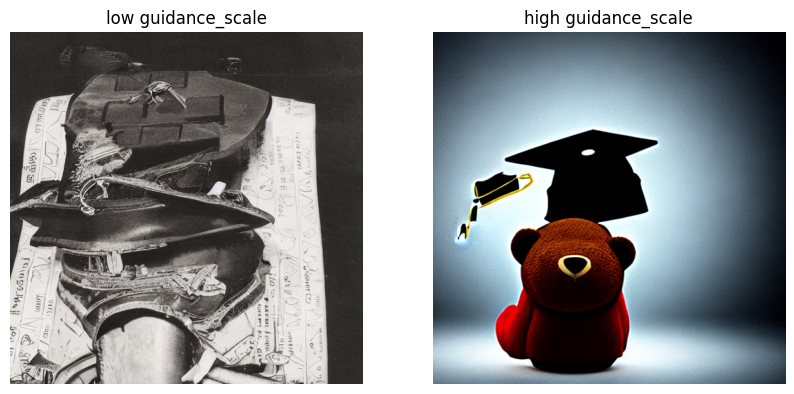

In [25]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=1.0).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=15.0).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* guidance_scale는 동일한 프롬프트와 동일한 num_inference_seps를 고정한 채 guidance_scale만 낮음과 높음으로 다르게 주어 같은 파이프라인을 두 번 호출해 두 이미지를 생성하고 비교하는 구조이다.


### **4-2. Sampler(Scheduler) 교체해보기**

발표자료 33p에서 언급했듯 Stable Diffusion은 하나로 고정된 모델이 아니라, denoising에 사용하는 sampler(scheduler)를 자유롭게 교체할 수 있는 구조입니다. 기본 스케줄러 대신 DDIM 스케줄러로 교체하여 더 적은 step으로도 이미지를 생성해봅니다.


  0%|          | 0/20 [00:00<?, ?it/s]

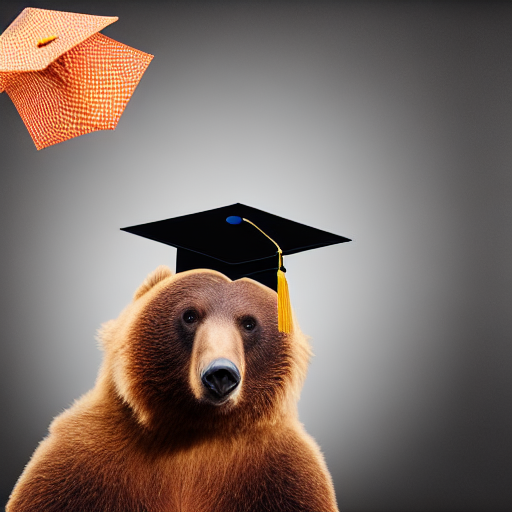

In [26]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

* DDPM은 학습 때와 동일한 Markov chain을 따라 매 timestep마다 순차적으로 노이즈를 샘플링해야 하므로 스텝을 건너뛰면 품질이 떨어지는 반면, DDIM은 forward process의 marginal은 유지하되 reverse process를 non-Markovian하게 재정의해 x_t로 x_0를 추정한 뒤 임의의 이른 시점으로 결정론적으로 점프하는 업데이트를 사용하기 때문에, 중간 step을 건너뛰어도 일관된 경로를 유지해 적은 step만으로 그럴듯한 이미지를 생성할 수 있다.


## **🙋 [Hugging Face] Question 3**
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)

- 허깅페이스 Space 3개를 활용해봤다. 먼저 black-forest-labs/FLUX.1-schnell은 텍스트 프롬프트로 이미지를 생성해주는 Space였는데, 한글 프롬프트는 잘 못 알아듣는 것 같았고 영어로 입력했을 때 비교적 정확한 결과가 나왔다. 다음으로 facebook/sapiens2-pose는 사진을 올리면 사람 관절을 자동으로 잡아 스켈레톤을 그려주는 자세 추정 데모였는데, 생각보다 정확하게 잡아내서 신기했다. briaai/BRIA-RMBG-2.0은 사진을 올리면 배경을 지워주는 Space였는데, 머리카락처럼 세밀한 부분은 깔끔하게 안 지워지고 살짝 뭉개지는 부분이 있었다. 세 개 모두 설치나 코드 작성 없이 브라우저에서 바로 결과를 확인할 수 있어서 편리했다.


## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (Part3 Diffusion의 개념을 한 번 더 자세히 확인하고 SimpleUNet 부분 코드가 잘 이해가 되지 않아서 코드 해설하는 데 사용했다. 다 작성한 후 검산을 위해 사용했다.)

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (SimpleUNet 코드의 upsampling부분을 설명할 때 출력 크기에 대해 잘못된 정보를 주는 경우가 있어서 직접 문서를 찾아봐야 했다.)

- **실제 대화 내역** 붙여넣기:

```
(# Diffusion Model (확산 모델)이란?

Diffusion Model은 현재 이미지 생성 AI(Stable Diffusion, DALL-E 2/3, Midjourney, Sora 등)의 핵심이 되는 생성 모델 방식입니다. 핵심 아이디어는 물리학에서 잉크가 물에 퍼지는 확산 현상에서 영감을 받았습니다. 잉크 방울이 물속에서 서서히 퍼져서 결국 완전히 섞인 상태(무질서, 노이즈)가 되는 것처럼, 이미지에 노이즈를 점진적으로 추가해서 완전한 노이즈로 만든 다음, 그 반대 과정을 학습해서 노이즈에서 다시 이미지를 복원하는 방식입니다.

## 기본 원리: 두 개의 과정

**정방향 과정 (Forward Process, Diffusion)**

원본 이미지에 아주 작은 가우시안 노이즈를 여러 단계(보통 수백에서 수천 스텝)에 걸쳐 반복적으로 추가합니다. 각 단계는 이전 단계보다 아주 조금씩만 노이즈가 많아지도록 설계되어 있고, 충분한 스텝을 거치면 원본 이미지의 정보는 완전히 사라지고 순수한 랜덤 노이즈(가우시안 분포)만 남습니다. 이 과정은 학습이 필요 없는 고정된 수학적 절차이며, 수식으로 표현하면 다음 스텝의 이미지는 이전 이미지에 약간의 노이즈를 섞은 것입니다.

**역방향 과정 (Reverse Process, Denoising)**

여기가 실제로 신경망이 학습하는 부분입니다. 노이즈가 잔뜩 낀 이미지에서 "한 스텝 전에는 어떤 모습이었을까"를 예측하도록 신경망(주로 U-Net 구조, 최근에는 Transformer 기반의 DiT도 많이 사용)을 훈련시킵니다. 학습이 끝나면, 완전한 랜덤 노이즈에서 출발해서 이 신경망으로 노이즈를 조금씩 제거해 나가는 과정을 반복하면, 마지막에는 그럴듯한 새로운 이미지가 만들어집니다.

## 학습 방식

신경망은 실제로 이미지 자체를 예측하는 게 아니라, 보통 "특정 스텝에서 어떤 노이즈가 더해졌는지"를 예측하도록 훈련됩니다. 즉 노이즈 낀 이미지와 그 노이즈가 몇 번째 스텝에서 얼마나 섞였는지를 입력으로 주면, 모델은 "여기에 섞인 노이즈가 정확히 이것이다"라고 맞히는 것을 목표로 학습합니다. 이렇게 노이즈를 정확히 예측할 수 있게 되면, 노이즈 낀 이미지에서 그 노이즈를 빼서 원본에 가까운 이미지를 복원할 수 있게 됩니다. 이 손실 함수는 비교적 단순한 평균제곱오차(MSE) 형태라서 학습이 안정적이라는 장점이 있습니다.

## 샘플링(이미지 생성) 과정

1. 완전히 무작위한 노이즈 이미지에서 시작합니다.
2. 학습된 신경망에게 "지금 이 이미지에 어떤 노이즈가 있는지" 예측하게 합니다.
3. 예측된 노이즈를 아주 조금만 제거합니다 (한 번에 다 제거하지 않고 조금씩).
4. 이 과정을 수십~수천 번 반복하면서 점점 더 선명한 이미지로 다듬어 나갑니다.
5. 최종적으로 노이즈가 완전히 제거되면 하나의 완성된 이미지가 남습니다.

이 반복적인 과정 때문에 생성 속도가 GAN보다 느리다는 단점이 있는데, 이를 해결하기 위해 DDIM, DPM-Solver 같은 빠른 샘플링 기법이나, 스텝 수를 크게 줄이는 distillation 기법들이 개발되었습니다.

## 텍스트로 이미지를 그리는 원리 (Conditional Diffusion)

Stable Diffusion처럼 "프롬프트를 입력하면 그림이 나오는" 모델은 위 과정에 조건(condition)을 추가한 것입니다. 텍스트를 CLIP 같은 텍스트 인코더로 벡터화한 뒤, 노이즈 제거 과정의 매 스텝마다 이 텍스트 벡터를 함께 참고하도록 만듭니다(주로 cross-attention 메커니즘 사용). 그러면 모델은 "이 텍스트에 어울리는 방향으로 노이즈를 제거"하게 되어, 결과적으로 텍스트 내용과 일치하는 이미지가 생성됩니다. Classifier-Free Guidance라는 기법을 함께 사용해서 텍스트 조건을 얼마나 강하게 따를지 조절하기도 합니다.

## Latent Diffusion — 왜 Stable Diffusion이 빠른가

원본 픽셀 공간(예: 512×512×3)에서 직접 노이즈 제거를 하면 계산량이 매우 큽니다. Stable Diffusion은 VAE(오토인코더)로 이미지를 훨씬 작은 잠재 공간(latent space, 예: 64×64×4)으로 압축한 뒤, 그 압축된 공간에서 확산·노이즈 제거 과정을 수행합니다. 그리고 마지막에 VAE 디코더로 다시 픽셀 이미지로 복원합니다. 이 덕분에 계산 비용이 크게 줄어 일반 GPU에서도 실행할 수 있게 되었습니다.

## GAN 등 다른 생성 모델과의 비교

GAN은 생성자와 판별자가 경쟁하며 학습하는 방식이라 학습이 불안정하고(mode collapse 등), 한 번의 forward pass로 빠르게 이미지를 만들 수 있다는 장점이 있습니다. 반면 Diffusion Model은 학습이 훨씬 안정적이고 다양성이 뛰어나며 화질도 우수하지만, 생성할 때 여러 스텝을 반복해야 해서 상대적으로 느립니다. 이런 이유로 2022년경부터 이미지 생성 분야의 주류가 GAN에서 Diffusion으로 넘어갔습니다.

## 활용 분야

이미지 생성(Stable Diffusion, DALL-E, Midjourney) 외에도 오디오 생성, 3D 모델 생성, 그리고 최근에는 동영상 생성(Sora, Runway 등)에도 Diffusion 기반 접근이 널리 쓰이고 있습니다. 최신 텍스트-투-비디오 모델들은 시공간적으로 확장된 형태의 diffusion 과정을 사용해 프레임 간 일관성을 유지하면서 영상을 생성합니다.

궁금하신 부분이 더 구체적으로 있으신가요? 예를 들어 수학적인 유도 과정(DDPM 논문 수식), Stable Diffusion 내부 구조, 아니면 실제로 Diffusion 모델을 직접 써보는 방법 등 더 깊이 들어가서 설명해 드릴 수 있습니다.


SimpleUNet 코드 설명

이 코드는 DDPM류 디퓨전 모델에서 노이즈를 예측하는 신경망(ε-예측 네트워크) 역할을 하는 작은 U-Net입니다. MNIST 같은 28×28 흑백 이미지를 대상으로 만들어진 축소판이고, 실제 Stable Diffusion의 U-Net과 구조상 원리는 같지만 훨씬 단순화되어 있습니다. 전체 흐름을 따라가면서 설명드릴게요.

## 1. 왜 U-Net이고, 왜 timestep을 입력받는가

디퓨전 모델의 신경망은 "노이즈 낀 이미지 `x`와 그 노이즈가 몇 번째 스텝(`t`)에서 얼마나 섞였는지"를 입력받아서, "여기에 섞인 노이즈가 무엇인지"를 예측합니다. 그래서 `forward(self, x, t)`처럼 이미지뿐 아니라 timestep `t`도 함께 받는 구조입니다. U-Net 구조를 쓰는 이유는 이미지를 다운샘플링하면서 전체적인(global) 맥락을 파악하고, 다시 업샘플링하면서 원래 해상도의 디테일(local)을 skip connection으로 복원하기 위해서입니다. 노이즈 제거는 결국 원본 해상도의 픽셀 단위 출력이 필요하기 때문에 이런 인코더-디코더+skip 구조가 잘 맞습니다.

## 2. Time embedding 부분

```python
self.time_mlp = nn.Sequential(
    TimeEmbedding(time_dim),
    nn.Linear(time_dim, time_dim),
    nn.ReLU()
)
```

`t`는 그냥 정수(0, 1, 2, … 스텝 번호)이기 때문에 신경망이 바로 다루기 어렵습니다. `TimeEmbedding`은 보통 Transformer의 positional encoding처럼 사인/코사인 함수를 이용해 정수 `t`를 `time_dim` 차원의 연속적인 벡터로 바꿔주는 모듈입니다(코드에는 정의부가 안 보이지만 이런 역할입니다). 그 뒤 `Linear + ReLU`를 한 번 더 거쳐서 이 벡터를 신경망이 더 잘 활용할 수 있는 형태로 변환합니다. 결과인 `t_emb`은 `(B, time_dim)` 형태의 벡터입니다.

## 3. Downsampling (인코더)

```python
h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)
```

`stride=2` 컨볼루션으로 해상도를 절반씩 줄이면서(28→14→7) 채널 수는 늘려갑니다(1→64→128→256). 해상도를 줄이는 대신 채널을 늘려서, 이미지의 세부 픽셀 정보 대신 더 추상적이고 전역적인 특징을 담도록 하는 전형적인 인코더 패턴입니다. `h1`, `h2`는 나중에 skip connection으로 디코더에 다시 전달하기 위해 따로 저장해둡니다.

## 4. 🤔 빈칸 — timestep 정보를 bottleneck에 주입하기

```python
t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)   # (B, 256, 1, 1)
h3 = h3 + t_proj                                              # (B, 256, 7, 7)
```

여기가 핵심 포인트입니다. `h3`는 `(B, 256, 7, 7)` 형태의 4차원 텐서(배치, 채널, 높이, 너비)인 반면, `t_emb`은 `(B, time_dim)` 형태의 2차원 벡터라서 형태가 맞지 않습니다. 그래서:

1. `self.time_proj`(Linear layer)로 `time_dim` → `256`으로 차원을 맞춰서, `h3`와 채널 수가 같은 벡터로 만들어줍니다.
2. `.unsqueeze(-1).unsqueeze(-1)`로 `(B, 256)` → `(B, 256, 1, 1)`로 차원을 두 개 늘려서 4차원 텐서 모양을 맞춥니다.
3. `h3 + t_proj`를 하면 PyTorch의 브로드캐스팅(broadcasting) 덕분에, `(B, 256, 1, 1)`의 값이 `(B, 256, 7, 7)`의 모든 공간 위치(7×7 전체)에 똑같이 더해집니다. 즉 각 채널마다 하나의 "이 timestep을 나타내는 값"을 이미지의 모든 픽셀 위치에 동일하게 더해주는 것입니다.

이렇게 하면 신경망은 "지금 노이즈 제거를 몇 번째 스텝에서 하고 있는지"를 특징맵 전체에 걸쳐 알 수 있게 됩니다. 스텝 초반(노이즈가 많이 남은 상태)과 후반(노이즈가 거의 없는 상태)에서 필요한 보정 방식이 다르기 때문에, 이 timestep 정보가 없으면 모델이 지금 몇 단계인지 전혀 알 수 없어 항상 똑같은 방식으로만 디노이징을 하게 됩니다. (참고로 실제 논문급 U-Net들은 이런 timestep 주입을 bottleneck 한 곳뿐 아니라 모든 해상도 단계의 residual block마다 넣는 게 일반적인데, 이 코드는 단순화를 위해 bottleneck 한 곳에서만 더해주고 있습니다.)

## 5. Bottleneck

```python
h3 = F.relu(self.bottleneck(h3))
```

가장 압축된 표현(7×7, 256채널)에 컨볼루션을 한 번 더 적용해서 특징을 정제합니다. 인코더의 끝이자 디코더의 시작점입니다.

## 6. Upsampling (디코더) + Skip Connection

```python
u1 = F.relu(self.up1(h3))          # (B, 128, 14, 14)
u1 = torch.cat([u1, h2], dim=1)     # (B, 256, 14, 14)
u1 = F.relu(self.up_conv1(u1))      # (B, 128, 14, 14)
```

`ConvTranspose2d`(전치 컨볼루션)로 해상도를 다시 2배로 늘립니다(7→14). 이때 그냥 업샘플링만 하면 다운샘플링 과정에서 손실된 세부 정보를 복원할 수 없기 때문에, 인코더에서 저장해뒀던 같은 해상도의 `h2`를 채널 방향으로 **concat**합니다(더하기가 아니라 이어붙이기라서 채널이 128+128=256이 됩니다). 그 다음 `up_conv1`으로 다시 채널 수를 128로 줄이면서 두 정보(업샘플링된 전역 정보 + skip으로 받은 지역 정보)를 섞습니다. `u2` 단계도 동일한 패턴으로 14→28 해상도, `h1`과 skip connection을 합니다.

skip connection에서 concat을 쓰는 이유는, 덧셈과 달리 두 정보를 섞지 않고 그대로 보존한 채 다음 레이어가 "둘을 어떻게 조합할지"를 학습하게 하기 위해서입니다(원조 U-Net 논문의 설계와 동일한 방식입니다).

## 7. 출력

```python
out = self.out(u2)   # (B, 1, 28, 28)
```

마지막 `1×1` 아니 `3×3` 컨볼루션으로 채널을 다시 1(흑백 이미지)로 줄여서, 입력 `x`와 동일한 shape의 텐서를 출력합니다. 이 출력이 바로 "이 시점 `t`에서 `x`에 섞여 있다고 예측한 노이즈(ε)"이며, 학습 시에는 실제로 섞은 노이즈와 이 예측값 사이의 MSE loss로 학습됩니다.

## 정리하면

입력 이미지를 점점 작은 해상도·많은 채널로 압축(인코더) → bottleneck에서 timestep 정보를 브로드캐스팅으로 주입 → 다시 원래 해상도로 복원하면서 인코더의 대응 레이어와 skip connection으로 디테일을 보존(디코더) → 최종적으로 입력과 같은 크기의 노이즈 예측값을 출력, 이라는 전형적인 조건부(timestep-conditioned) U-Net 구조입니다.
)
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? (개념에 대해 설명할 때 너무 많은 양의 정보를 주기 때문에 오히려 이해하기 어려웠던 부분이 있어서 AI 보다 직접 찾아보는게 더 이해하기 쉬웠던 경우가 있었다.)


수고하셨습니다 ☺️